# Lab: Energy Loss in Open-Channel Flow

## Nomenclature

| Symbol   | Description                                     | Unit  |
| -------- | ----------------------------------------------- | ----- |
| $y$      | Flow depth                                      | m     |
| $l$      | Sloping distance measured along the channel bed | m     |
| $z$      | Elevation above the datum                       | m     |
| $V$      | Average flow velocity                           | m/s   |
| $Q$      | Flow rate (discharge)                           | m³/s  |
| $A$      | Cross-sectional flow area                       | m²    |
| $B$      | Channel width                                   | m     |
| $\theta$ | Channel bed slope angle                         | °     |
| $\rho$   | Density of water                                | kg/m³ |
| $g$      | Gravitational acceleration                      | m/s²  |
| $h_L$    | Head loss between two sections                  | m     |
| $H$      | Total energy head                               | m     |


## 1. Background

This experiment investigates energy losses in open-channel flow by measuring the water-surface elevations at different locations along the channel. The experimental setup is illustrated in Figure 1.
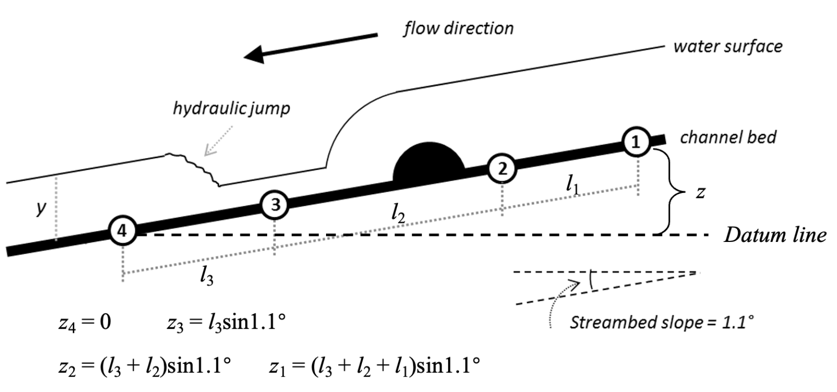

The flow rate is maintained at

$$
Q = 0.005 ,\text{m}^3/\text{s}.
$$

The flow depth ($y$), bed elevation ($z$), and sloping distance ($l$) are measured at four locations along the channel.

The water used in the experiment is assumed to have a density of

$$
\rho = 1000 ,\text{kg/m}^3.
$$

## 2. Measurement Results

As shown in Figure 1, the channel bed has a slope angle of

$$
\theta = 1.1^\circ.
$$

A horizontal line passing through point $z_4$ is selected as the datum. The measured values are summarized below.


In [53]:
import pandas as pd
import numpy as np

# Create DataFrame
df = pd.DataFrame({
    "Point": [1, 2, 3, 4],
    "l (m)": [2.7, 1.8, 1.3, 0.0],
    "y (m)": [0.0765, 0.096, 0.021, 0.084]
})
df['z (m)'] = df['l (m)'] * np.sin(np.radians(1.1))
df

,Point,l (m),y (m),z (m)
0,1,2.7,0.0765,0.051833
1,2,1.8,0.0960,0.034555
2,3,1.3,0.0210,0.024957
3,4,0.0,0.0840,0.000000


## 3. Calculations

### 3.1 Cross-Sectional Area of the Flow and Average Flow Velocity

The open channel has a rectangular cross section with a width of

$$
B = 0.20 ,\text{m}.
$$

The cross-sectional flow area is calculated as

$$
A = B \times y
$$

where

* $A$ = cross-sectional area ($\text{m}^2$)
* $B$ = channel width (m)
* $y$ = flow depth (m)

Using the continuity equation, the average flow velocity at each measurement location can be calculated as

$$
V = \frac{Q}{A}
$$

where

* $V$ = average flow velocity (m/s)
* $Q$ = flow rate ($\text{m}^3/\text{s}$)
* $A$ = cross-sectional flow area ($\text{m}^2$)



In [54]:
Q = 0.005
B = 0.2
df['A (m2)'] = df['y (m)'] * B
df['V (m/s)'] = Q / df['A (m2)']
df

,Point,l (m),y (m),z (m),A (m2),V (m/s)
0,1,2.7,0.0765,0.051833,0.0153,0.326797
1,2,1.8,0.0960,0.034555,0.0192,0.260417
2,3,1.3,0.0210,0.024957,0.0042,1.190476
3,4,0.0,0.0840,0.000000,0.0168,0.297619


### 3.2 Energy Loss

Based on the energy equation for open-channel flow, the head loss between two measurement sections can be calculated. The kinetic-energy correction factor is assumed to be

$$
\alpha = 1.
$$

The total energy head at a section is

$$
H = z + y + \alpha \frac{V^2}{2g}
$$

where

* $z$ = bed elevation above the datum (m)
* $y$ = flow depth (m)
* $V$ = average flow velocity (m/s)

The head loss between two sections is therefore

$$
h_f = H_1 - H_2
$$


#### 3.2a Energy Loss Between Points 1 and 2

$$
h_{f,12}
=
\left(
z_1+y_1+\frac{V_1^2}{2g}
\right)
-
\left(
z_2+y_2+\frac{V_2^2}{2g}
\right)
=
-0.00023 \,\text{m} \approx 0 \,\text{m}.
$$

The energy loss between Points 1 and 2 is mainly caused by boundary friction along the channel bed and side walls. This loss is associated with the shear stress generated between the flowing water and the channel boundaries. Since the value is very close to zero, the small negative result is likely due to measurement uncertainty and rounding errors. Therefore, the energy loss between Points 1 and 2 is considered negligible.

In [55]:
g = 9.8

hf12 = (df.loc[0, 'z (m)'] + df.loc[0, 'y (m)'] + df.loc[0, 'V (m/s)']**2/(2*g)
        - df.loc[1, 'z (m)'] - df.loc[1, 'y (m)'] - df.loc[1, 'V (m/s)']**2/(2*g))

print("hf-12", hf12)

hf-12 -0.00023354209686669326


#### 3.2b Energy Loss Between Points 2 and 3

$$
h_{f,23}
=
\left(
z_2+y_2+\frac{V_2^2}{2g}
\right)
-
\left(
z_3+y_3+\frac{V_3^2}{2g}
\right)
= 0.01575 \,\text{m}.
$$

The energy loss between Points 2 and 3 is primarily caused by flow separation and turbulence generated by the bump. As the flow passes over the obstruction, additional energy is dissipated due to local disturbances in the velocity field.


In [56]:
hf23 = ( df.loc[1, 'z (m)'] + df.loc[1, 'y (m)'] + df.loc[1, 'V (m/s)']**2/(2*g)
    - df.loc[2, 'z (m)'] - df.loc[2, 'y (m)'] - df.loc[2, 'V (m/s)']**2/(2*g))

print("hf-23: ", hf23)

hf-23:  0.015750929372654793


#### 3.2c Energy Loss Between Points 3 and 4

$$
h_{f,34}
=
\left(
z_3+y_3+\frac{V_3^2}{2g}
\right)
-
\left(
z_4+y_4+\frac{V_4^2}{2g}
\right)
= 0.029745 \,\text{m}.
$$

The energy loss between Points 3 and 4 is mainly associated with the hydraulic jump. A large amount of energy is dissipated through intense turbulence, mixing, and eddy formation as the flow transitions from a supercritical state to a subcritical state.


In [57]:
hf34 = ( df.loc[2, 'z (m)'] + df.loc[2, 'y (m)'] + df.loc[2, 'V (m/s)']**2/(2*g)
    - df.loc[3, 'z (m)'] - df.loc[3, 'y (m)'] - df.loc[3, 'V (m/s)']**2/(2*g) )

print("hf-34:", hf34)

hf-34: 0.029745270149445217


### 3.3 Specific Force

The specific force is calculated using the momentum equation. Assuming the momentum correction coefficient is

$$
\beta = 1,
$$

the specific force is given by

$$
P_s = \rho g A h_{tp} + \beta \rho Q V
$$

where

* $P_s$ = specific force (N)
* $\rho$ = density of water ($\mathrm{kg/m^3}$)
* $g$ = gravitational acceleration ($\mathrm{m/s^2}$)
* $A$ = cross-sectional flow area ($\mathrm{m^2}$)
* $h_{tp}$ = depth of the centroid below the free surface (m)
* $Q$ = flow rate ($\mathrm{m^3/s}$)
* $V$ = average flow velocity ($\mathrm{m/s}$)

For a rectangular channel,

$$
h_{tp}
=
\frac{y}{2}
$$

Therefore,

$$
P_s
=
\rho g A \frac{y}{2}
+
\rho Q V
$$

The specific force is calculated at Points 3 and 4 to examine whether momentum is conserved across the hydraulic jump.



In [58]:
rho = 1000
g = 9.8
beta = 1

df['Ps (N)'] = (
    rho * g * df['A (m2)'] * df['y (m)'] / 2
    + beta * rho * Q * df['V (m/s)']
)

df

,Point,l (m),y (m),z (m),A (m2),V (m/s),Ps (N)
0,1,2.7,0.0765,0.051833,0.0153,0.326797,7.369192
1,2,1.8,0.0960,0.034555,0.0192,0.260417,10.333763
2,3,1.3,0.0210,0.024957,0.0042,1.190476,6.384561
3,4,0.0,0.0840,0.000000,0.0168,0.297619,8.402975


The calculated specific forces at Points 3 and 4 are

$$
P_{s,3} = 6.38 \,\text{N}
$$

and

$$
P_{s,4} = 8.40 \,\text{N}.
$$

The two values are not exactly equal. In theory, the specific force should be approximately conserved across a hydraulic jump, because the jump is usually analysed using the momentum equation. The difference in the calculated values may be caused by measurement uncertainty in the flow depth, non-uniform velocity distribution, turbulence and air entrainment in the hydraulic jump, and the assumption that the momentum correction coefficient is $\beta = 1$.

Another possible reason is that Points 3 and 4 are not be located exactly at the sections immediately before and after the hydraulic jump. Therefore, additional friction losses and local flow disturbances may affect the calculated specific force.

The calculated specific forces are

$$
P_{s,3} = 6.38 \,\text{N}
$$

and

$$
P_{s,4} = 8.40 \,\text{N}.
$$

Theoretically, the specific force should be approximately conserved across a hydraulic jump. However, the calculated values are not equal. This discrepancy is likely caused by measurement uncertainty, especially because the water surface before and within the hydraulic jump was unstable and difficult to read accurately. Since Point 3 has a very small measured depth of only $2.1\ \text{cm}$, even a small reading error can significantly affect the calculated area, velocity, and specific force.

Therefore, the difference between $P_{s,3}$ and $P_{s,4}$ is most likely due to experimental measurement errors rather than a failure of the momentum principle.

In [46]:
q = Q/B
yc = (q ** 2 / g) ** (1/3)
yc

0.039953176502907035